# Step 1

Loading the training data


In [1]:
import pandas as pd

train_df = pd.read_csv('train.csv')
print(train_df.shape)
print(train_df.head())

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


(17000, 2)
      Id  Category
0   7168         6
1   9876         3
2  78117         6
3   9626         1
4  29492         3


Understanding distribution of the training data

In [2]:
print(train_df['Category'].value_counts().sort_index())

Category
0    1700
1    1700
2    1700
3    1700
4    1700
5    1700
6    1700
7    1700
8    1700
9    1700
Name: count, dtype: int64


Going through the directory to understand training data

In [3]:
import os
import os
files = os.listdir('train/train/0')
print(files[:10])
print(len(files))

['76271.png', '39566.png', '76265.png', '39572.png', '6831.png', '76259.png', '6825.png', '9525.png', '44566.png', '39599.png']
1700


Loading a file to understand the shape of file

(32, 32)
0.0 0.99607843


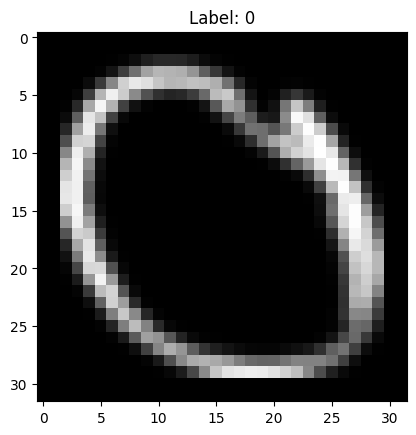

In [4]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread('train/train/0/76271.png')
print(img.shape)
print(img.min(), img.max())
plt.imshow(img, cmap='gray')
plt.title('Label: 0')
plt.show()

# Step 2

Loading the data for training

In [5]:
import numpy as np

X = []
y = []

for label in range(10):
    folder = f'train/train/{label}'
    for filename in os.listdir(folder):
        img = mpimg.imread(f'{folder}/{filename}')
        X.append(img)
        y.append(label)

X = np.array(X)
y = np.array(y)

# Add channel dimension
X = X.reshape(-1, 32, 32, 1)

print(X.shape)
print(y.shape)

(17000, 32, 32, 1)
(17000,)


# Step 3


Splitting the data

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_val.shape)

(13600, 32, 32, 1)
(3400, 32, 32, 1)


# Step 4


Build the CNN

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    # Block 1
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,1)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    # Classifier
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model.summary()

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 591,978 (2.26 MB)

 Trainable params: 591,338 (2.26 MB)

 Non-trainable params: 640 (2.50 KB)

# Step 5

Compile


In [8]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Step 6

Train

In [9]:
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_val, y_val)
)

Epoch 1/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 20s 86ms/step - accuracy: 0.9146 - loss: 0.2767 - val_accuracy: 0.1000 - val_loss: 7.2389
Epoch 2/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 18s 85ms/step - accuracy: 0.9816 - loss: 0.0682 - val_accuracy: 0.2206 - val_loss: 3.5120
Epoch 3/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 18s 84ms/step - accuracy: 0.9876 - loss: 0.0425 - val_accuracy: 0.9700 - val_loss: 0.0953
Epoch 4/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 19s 87ms/step - accuracy: 0.9929 - loss: 0.0284 - val_accuracy: 0.9935 - val_loss: 0.0208
Epoch 5/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 21s 97ms/step - accuracy: 0.9930 - loss: 0.0260 - val_accuracy: 0.9974 - val_loss: 0.0091
Epoch 6/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 20s 92ms/step - accuracy: 0.9957 - loss: 0.0178 - val_accuracy: 0.9974 - val_loss: 0.0088
Epoch 7/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 20s 93ms/step - accuracy: 0.9940 - loss: 0.0196 - val_accuracy: 0.9965 - val_loss: 0.0106
Epoch 8/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 20s 92ms/step - accuracy: 0.9956 - loss: 0.0155 - 

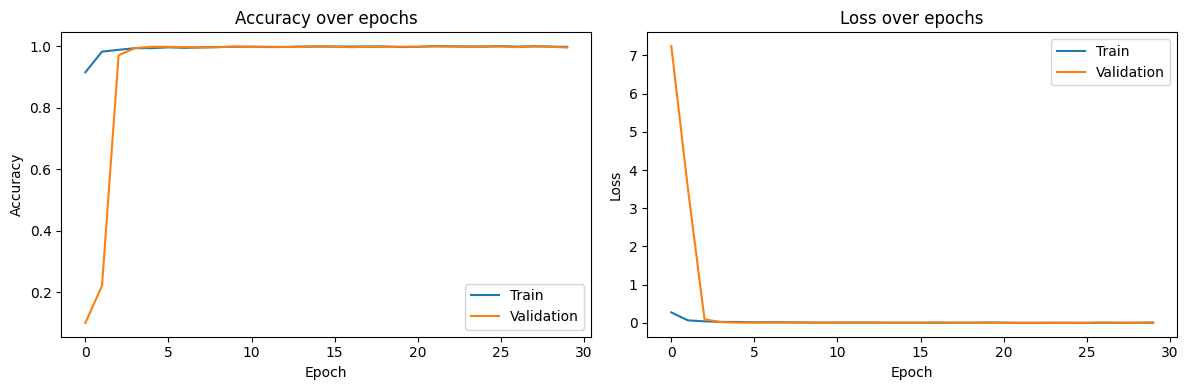

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [14]:
X_test = []
test_ids = []

for _, row in test_df.iterrows():
    img_id = row['Id']
    img = mpimg.imread(f'test/test/{img_id}.png')
    X_test.append(img)
    test_ids.append(img_id)

X_test = np.array(X_test)
X_test = X_test.reshape(-1, 32, 32, 1)

print(X_test.shape)
print(len(test_ids))

(3000, 32, 32, 1)
3000


In [15]:
# Get predictions
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)

# Create submission dataframe
submission = pd.DataFrame({
    'Id': test_ids,
    'Category': predicted_classes
})

submission.to_csv('submission.csv', index=False)
print(submission.head(10))
print(submission.shape)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
      Id  Category
0  56604         6
1  29396         3
2  43803         6
3  12313         0
4  10341         8
5  40355         3
6  41117         4
7  71324         7
8   6854         1
9  12761         8
(3000, 2)
